In [1]:
# !pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124

In [2]:
import torch
import numpy as np
import cv2
from matplotlib import pyplot as plt
from ultralytics import YOLO

In [3]:
model = YOLO('yolo11n')

In [4]:
model

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_


Found https://ultralytics.com/images/zidane.jpg locally at zidane.jpg
image 1/1 C:\Users\user\OneDrive\Documents\Computer Vision\Intermidate_projects\face_recognition\Emotion_detection\zidane.jpg: 384x640 2 persons, 1 tie, 174.8ms
Speed: 15.4ms preprocess, 174.8ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)


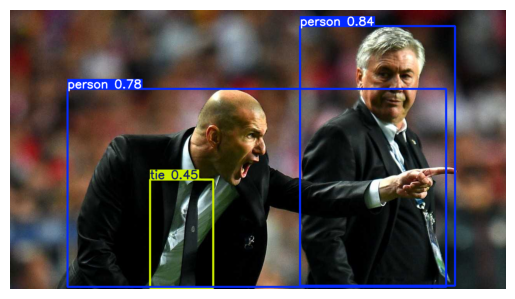

In [5]:
img = 'https://ultralytics.com/images/zidane.jpg'
results = model(img)
# print(results)
for result in results:
    if hasattr(result, "plot"):  # Check if the 'plot' method exists
        rendered_image = result.plot()  # Plot and return the image
        plt.imshow(cv2.cvtColor(rendered_image, cv2.COLOR_BGR2RGB))
        # plt.imshow(rendered_image)
        plt.axis('off')
        plt.show()
    else:
        print("Plot method is not available for this result.")



image 1/1 C:\Users\user\OneDrive\Documents\Computer Vision\Intermidate_projects\face_recognition\Emotion_detection\800px-Cars_in_traffic_in_Auckland,_New_Zealand_-_copyright-free_photo_released_to_public_domain.jpg: 448x640 38 cars, 6 trucks, 172.3ms
Speed: 11.0ms preprocess, 172.3ms inference, 15.7ms postprocess per image at shape (1, 3, 448, 640)


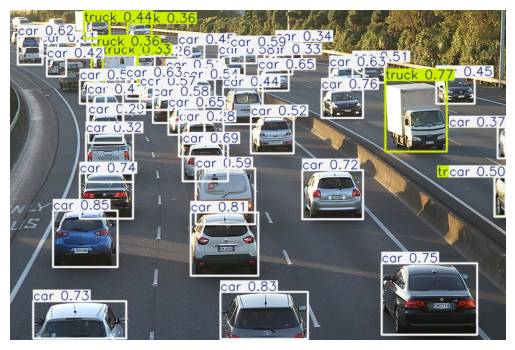

In [6]:
img = "./800px-Cars_in_traffic_in_Auckland,_New_Zealand_-_copyright-free_photo_released_to_public_domain.jpg"
results = model(img)
# print(results)
for result in results:
    if hasattr(result, "plot"):  # Check if the 'plot' method exists
        rendered_image = result.plot()  # Plot and return the image
        plt.imshow(cv2.cvtColor(rendered_image, cv2.COLOR_BGR2RGB))
        # plt.imshow(rendered_image)
        plt.axis('off')
        plt.show()
    else:
        print("Plot method is not available for this result.")


In [7]:
# import cv2
# import numpy as np

cap = cv2.VideoCapture(0)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Make detections (replace `model` with your actual YOLO model instance)
    results = model(frame)

    # Check if results is a list and handle appropriately
    if isinstance(results, list):
        for result in results:
            if hasattr(result, "plot"):
                # Use the plot method if available
                rendered_frame = np.squeeze(result.plot())
                cv2.imshow('YOLO', rendered_frame)
    elif hasattr(results, "plot"):
        # If results itself has a plot method
        rendered_frame = np.squeeze(results.plot())
        cv2.imshow('YOLO', rendered_frame)
    else:
        print("Results do not have a render or plot method.")
        cv2.imshow('YOLO', frame)  # Display raw frame if no rendering is possible

    # Quit on 'q' key
    if cv2.waitKey(10) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()



0: 480x640 1 person, 227.1ms
Speed: 2.0ms preprocess, 227.1ms inference, 3.8ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 312.9ms
Speed: 10.8ms preprocess, 312.9ms inference, 0.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 200.2ms
Speed: 7.1ms preprocess, 200.2ms inference, 2.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 229.4ms
Speed: 7.0ms preprocess, 229.4ms inference, 0.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 174.4ms
Speed: 0.0ms preprocess, 174.4ms inference, 0.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 158.3ms
Speed: 11.1ms preprocess, 158.3ms inference, 0.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 146.5ms
Speed: 0.0ms preprocess, 146.5ms inference, 0.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 137.0ms
Speed: 4.0ms preprocess, 137.0ms inference, 0.0ms postprocess per image 

In [8]:
import uuid   # Unique identifier
import os
import time

In [25]:
IMAGES_PATH = os.path.join('data', 'images')  #/data/images
labels = ['happy', 'sad', 'angry', 'disgust', 'fear', 'surpise', ] # classes 'awake', 'drowsy',
number_imgs = 10 # number of images in the dataset

In [10]:
cap = cv2.VideoCapture(0)
# Loop through labels
for label in labels:
    print('Collecting images for {}'.format(label))
    time.sleep(5)
    
    # Loop through image range
    for img_num in range(number_imgs):
        print('Collecting images for {}, image number {}'.format(label, img_num))
        
        # Webcam feed
        ret, frame = cap.read()
        
        # Naming out image path
        imgname = os.path.join(IMAGES_PATH, label+'.'+str(uuid.uuid1())+'.jpg')
        
        # Writes out image to file 
        cv2.imwrite(imgname, frame)
        
        # Render to the screen
        cv2.imshow('Image Collection', frame)
        
        # 2 second delay between captures
        time.sleep(2)
        
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break
cap.release()
cv2.destroyAllWindows()

In [26]:
model = YOLO('./best.pt')

In [27]:
model

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(96, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(128, eps=0.001, momentum=0.03, affine=True, track_runnin

In [28]:
img = os.path.join('data', 'awake.82b99a53-d44c-11ef-a9a6-7470fd886caa.jpg')

In [29]:
results = model(img)


image 1/1 C:\Users\user\OneDrive\Documents\Computer Vision\Intermidate_projects\face_recognition\Emotion_detection\data\awake.82b99a53-d44c-11ef-a9a6-7470fd886caa.jpg: 416x544 1 neutral, 500.4ms
Speed: 10.1ms preprocess, 500.4ms inference, 7.5ms postprocess per image at shape (1, 3, 416, 544)


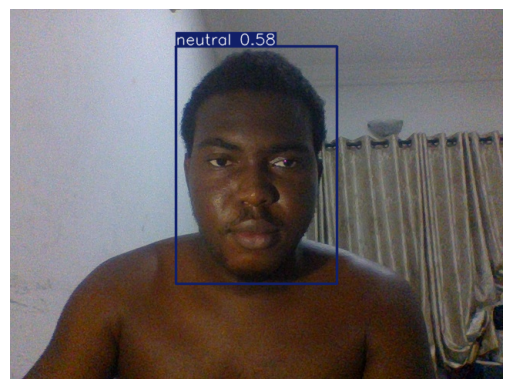

In [30]:
for result in results:
    if hasattr(result, "plot"):  # Check if the 'plot' method exists
        rendered_image = result.plot()  # Plot and return the image
        plt.imshow(cv2.cvtColor(rendered_image, cv2.COLOR_BGR2RGB))
        # plt.imshow(rendered_image)
        plt.axis('off')
        plt.show()
    else:
        print("Plot method is not available for this result.")

In [31]:
# import cv2
# import numpy as np

cap = cv2.VideoCapture(0)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Make detections (replace `model` with your actual YOLO model instance)
    results = model(frame)

    # Check if results is a list and handle appropriately
    if isinstance(results, list):
        for result in results:
            if hasattr(result, "plot"):
                # Use the plot method if available
                rendered_frame = np.squeeze(result.plot())
                cv2.imshow('YOLO', rendered_frame)
    elif hasattr(results, "plot"):
        # If results itself has a plot method
        rendered_frame = np.squeeze(results.plot())
        cv2.imshow('YOLO', rendered_frame)
    else:
        print("Results do not have a render or plot method.")
        cv2.imshow('YOLO', frame)  # Display raw frame if no rendering is possible

    # Quit on 'q' key
    if cv2.waitKey(10) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


0: 416x544 (no detections), 466.3ms
Speed: 4.9ms preprocess, 466.3ms inference, 0.0ms postprocess per image at shape (1, 3, 416, 544)

0: 416x544 (no detections), 461.2ms
Speed: 5.6ms preprocess, 461.2ms inference, 0.0ms postprocess per image at shape (1, 3, 416, 544)

0: 416x544 (no detections), 348.6ms
Speed: 7.6ms preprocess, 348.6ms inference, 2.1ms postprocess per image at shape (1, 3, 416, 544)

0: 416x544 (no detections), 337.7ms
Speed: 7.8ms preprocess, 337.7ms inference, 0.0ms postprocess per image at shape (1, 3, 416, 544)

0: 416x544 (no detections), 333.8ms
Speed: 7.6ms preprocess, 333.8ms inference, 0.0ms postprocess per image at shape (1, 3, 416, 544)

0: 416x544 (no detections), 288.4ms
Speed: 6.6ms preprocess, 288.4ms inference, 0.0ms postprocess per image at shape (1, 3, 416, 544)

0: 416x544 (no detections), 292.1ms
Speed: 5.2ms preprocess, 292.1ms inference, 0.0ms postprocess per image at shape (1, 3, 416, 544)

0: 416x544 (no detections), 292.5ms
Speed: 6.4ms prepr

In [11]:
# !git clone https://github.com/tzutalin/labelImg
# pip3 install labelImg
# labelImg                               for calling the app

# LabelImg is now label-studio, here is how to install it app on windows.

# # Requires Python >=3.8
# pip install label-studio

# # Start the server at http://localhost:8080
# label-studio                           for calling the app

In [12]:
# !pip install pyqt5 lxml --upgrade
# !cd labelImg && pyrcc5 -o libs/resources.py resources.qrc

In [13]:
# !pip install pyqt5 lxml --upgrade

In [14]:
# !yolo detect train data="C:\Users\user\OneDrive\Documents\Computer Vision\Intermidate_projects\face_recognition\Emotion_detection\Data\project-1-at-2025-01-17-00-36-8b2961e6\data.yaml" model=yolo11n.pt epochs=30 imgsz=540